In [2]:
# Librerías

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Cargamos el archivo usando la tercera fila como encabezado

Leads = pd.read_csv("Analisis GAC Full7agosto 2026(Leads Reales).csv", header=2)

In [4]:
Leads.head()

,Año,Mes,Total,Ilocalizable,No Contesta,D. Incorrectos,Duplicados,Efectivos,Abiertos,Ventas,Conversion,Efectividad de Leads,Unnamed: 12,Unnamed: 13
0,2024.0,Enero,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Febrero,543,108,33,0,1,389,1,12,3.1%,72%,NaN,NaN
2,NaN,Marzo,178,37,13,0,0,128,1,7,5.5%,72%,NaN,NaN
3,NaN,Abril,416,79,46,3,0,288,1,8,2.8%,69%,NaN,NaN
4,NaN,Mayo,422,33,100,17,0,274,5,13,4.7%,65%,NaN,NaN


In [5]:
# Eliminamos espacios sobrantes de los nombres de las columnas

Leads.columns = Leads.columns.str.strip()


# Eliminamos las columnas llamadas unnamed

Leads = Leads.loc[:, ~Leads.columns.str.contains("Unnamed")]


# Mostramos los nombres de las columnas

Leads.columns

Index(['Año', 'Mes', 'Total', 'Ilocalizable', 'No Contesta', 'D. Incorrectos',
       'Duplicados', 'Efectivos', 'Abiertos', 'Ventas', 'Conversion',
       'Efectividad de Leads'],
      dtype='str')

In [6]:
# Eliminamos espacios de la columna mes

Leads["Mes"] = Leads["Mes"].astype(str).str.strip()


# Convertimos año a numérico y completamos los años faltantes

Leads["Año"] = pd.to_numeric(Leads["Año"], errors="coerce").ffill()

In [7]:
# Lista de meses válidos

meses = ["Enero", "Febrero", "Marzo", "Abril", "Mayo", "Junio", "Julio", "Agosto", "Septiembre", "Octubre", "Noviembre", "Diciembre"]


# Filtramos solamente los registros mensuales

Leads = Leads[Leads["Mes"].isin(meses)]

In [8]:
# Variables que vamos a categorizar

variables = ["Total", "Ilocalizable", "No Contesta", "D. Incorrectos", "Duplicados", "Efectivos", "Abiertos", "Ventas", "Conversion", "Efectividad de Leads"]

In [9]:
# Convertimos las variables a valores numéricos

for columna in variables:
    Leads[columna] = Leads[columna].astype(str)
    Leads[columna] = Leads[columna].str.replace(",", "")
    Leads[columna] = Leads[columna].str.replace("%", "")
    Leads[columna] = pd.to_numeric(Leads[columna], errors="coerce")

In [10]:
# Eliminamos los registros que tengan nulos en las variables

Leads = Leads.dropna(subset=variables)


# Reiniciamos el índice

Leads = Leads.reset_index(drop=True)

In [11]:
# Dimensiones finales

print("Dimensiones:", Leads.shape)


# Valores nulos

Leads[variables].isnull().sum()

Dimensiones: (28, 12)


Total                   0
Ilocalizable            0
No Contesta             0
D. Incorrectos          0
Duplicados              0
Efectivos               0
Abiertos                0
Ventas                  0
Conversion              0
Efectividad de Leads    0
dtype: int64

In [12]:
# Número de observaciones

n = len(Leads)

print("Número de observaciones:", n)

Número de observaciones: 28


In [13]:
# Valor máximo y mínimo de Total

Max_Total = Leads["Total"].max()
Min_Total = Leads["Total"].min()

Limites_Total = [Min_Total, Max_Total]
Limites_Total

[np.float64(178.0), np.float64(1973.0)]

In [14]:
# Rango de Total

R_Total = Max_Total - Min_Total
R_Total

np.float64(1795.0)

In [15]:
# Regla de Sturges

ni = 1 + 3.32 * np.log10(n)

print("Número de intervalos sin redondear:", ni)

Número de intervalos sin redondear: 5.8045646640561674


In [16]:
# Número de intervalos

numero_intervalos = round(ni)
numero_intervalos

6

In [17]:
# Ancho de cada intervalo

i_Total = R_Total / numero_intervalos
i_Total

np.float64(299.1666666666667)

In [18]:
# Intervalos para la variable Total

intervalos_Total = np.linspace(177, 1974, 7)
intervalos_Total

array([ 177. ,  476.5,  776. , 1075.5, 1375. , 1674.5, 1974. ])

In [19]:
# Nombres de categorías

categorias_Total = ["177-477","477-776",
                    "776-1076","1076-1375",
                    "1375-1675","1675-1974"]

In [20]:
# Categorizar variable Total

Leads["Total"] = pd.cut(x=Leads["Total"], bins=intervalos_Total,labels=categorias_Total)

Leads["Total"]

0       477-776
1       177-477
2       177-477
3       177-477
4      776-1076
5      776-1076
6     1375-1675
7     1076-1375
8     1675-1974
9     1375-1675
10    1076-1375
11     776-1076
12      477-776
13     776-1076
14    1076-1375
15     776-1076
16    1076-1375
17    1076-1375
18    1375-1675
19    1076-1375
20    1076-1375
21     776-1076
22    1375-1675
23    1375-1675
24    1076-1375
25    1675-1974
26    1375-1675
27    1076-1375
Name: Total, dtype: category
Categories (6, str): ['177-477' < '477-776' < '776-1076' < '1076-1375' < '1375-1675' < '1675-1974']

In [21]:
# Frecuencia de las categorías

Tabla_Total = Leads["Total"].value_counts().reset_index()
Tabla_Total

,Total,count
0,1076-1375,9
1,776-1076,6
2,1375-1675,6
3,177-477,3
4,477-776,2
5,1675-1974,2


In [22]:
# Categorías con frecuencia mayor a cero

Filtro_Total = Tabla_Total[Tabla_Total["count"] > 0]
Filtro_Total

,Total,count
0,1076-1375,9
1,776-1076,6
2,1375-1675,6
3,177-477,3
4,477-776,2
5,1675-1974,2


In [23]:
# Ajustamos índice 

Filtro_Total_index = Filtro_Total.set_index("Total")
Filtro_Total_index

,count
Total,
1076-1375,9
776-1076,6
1375-1675,6
177-477,3
477-776,2
1675-1974,2


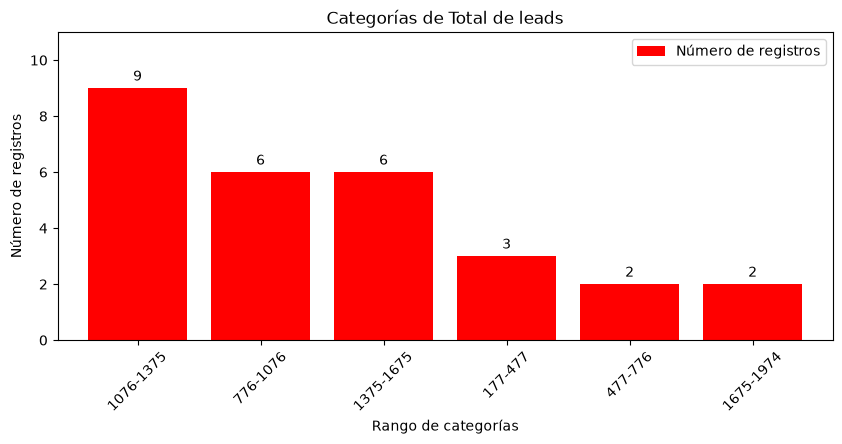

In [77]:
# Gráfica de barras 1: Total

ax = Filtro_Total_index.plot(kind="bar", width=0.8,figsize=(10,4),color="red", rot=45)

ax.bar_label(ax.containers[0], padding=3)

plt.ylim(0, Filtro_Total_index["count"].max() + 2)


plt.title("Categorías de Total de leads")
plt.xlabel("Rango de categorías")
plt.ylabel("Número de registros")
plt.legend(["Número de registros"])
plt.show()

In [25]:
# Valor máximo y mínimo de Ilocalizable

Max_Ilocalizable = Leads["Ilocalizable"].max()
Min_Ilocalizable = Leads["Ilocalizable"].min()

Limites_Ilocalizable = [Min_Ilocalizable, Max_Ilocalizable]
Limites_Ilocalizable

[np.float64(5.0), np.float64(514.0)]

In [26]:
# Rango de Ilocalizable

R_Ilocalizable = Max_Ilocalizable - Min_Ilocalizable
R_Ilocalizable

np.float64(509.0)

In [27]:
# Ancho de cada intervalo

i_Ilocalizable = R_Ilocalizable / numero_intervalos
i_Ilocalizable

np.float64(84.83333333333333)

In [28]:
# Intervalos para Ilocalizable

intervalos_Ilocalizable = np.linspace(4, 515, 7)
intervalos_Ilocalizable

array([  4.        ,  89.16666667, 174.33333333, 259.5       ,
       344.66666667, 429.83333333, 515.        ])

In [29]:
# Categorías con sus rangos

categorias_Ilocalizable = ["4-89","89-174",
                           "174-260","260-345",
                           "345-430","430-515"]

In [30]:
# Categorizar variable Ilocalizable

Leads["Categoria Ilocalizable"] = pd.cut(x=Leads["Ilocalizable"],bins=intervalos_Ilocalizable,labels=categorias_Ilocalizable)

Leads[["Ilocalizable", "Categoria Ilocalizable"]].head()

,Ilocalizable,Categoria Ilocalizable
0,108.0,89-174
1,37.0,4-89
2,79.0,4-89
3,33.0,4-89
4,140.0,89-174


In [31]:
# Frecuencia de las categorías

Tabla_Ilocalizable = Leads["Categoria Ilocalizable"].value_counts().reset_index()

Tabla_Ilocalizable

,Categoria Ilocalizable,count
0,4-89,13
1,89-174,9
2,430-515,3
3,174-260,2
4,345-430,1
5,260-345,0


In [32]:
# Categorías con frecuencia mayor a cero

Filtro_Ilocalizable = Tabla_Ilocalizable[Tabla_Ilocalizable["count"] > 0]

Filtro_Ilocalizable

,Categoria Ilocalizable,count
0,4-89,13
1,89-174,9
2,430-515,3
3,174-260,2
4,345-430,1


In [33]:
# Ajustamos índice 

Filtro_Ilocalizable_index = Filtro_Ilocalizable.set_index("Categoria Ilocalizable")

Filtro_Ilocalizable_index

,count
Categoria Ilocalizable,
4-89,13
89-174,9
430-515,3
174-260,2
345-430,1


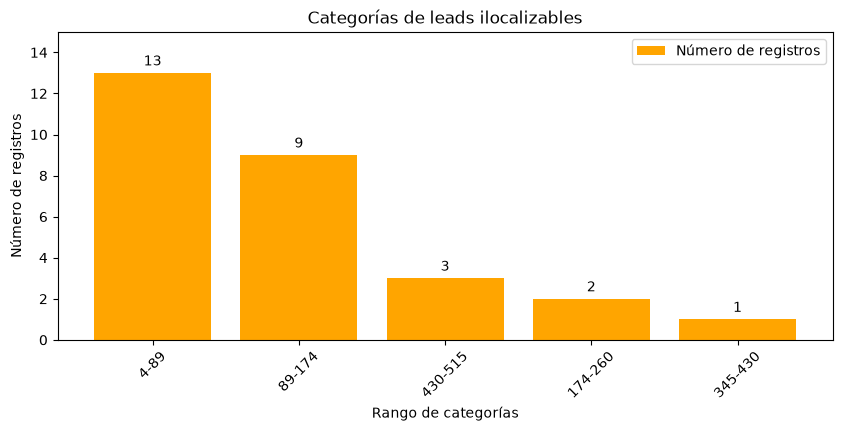

In [36]:
# Gráfica de barras 2: Ilocalizables

ax = Filtro_Ilocalizable_index.plot(kind="bar", width=0.8, figsize=(10,4), color="orange", rot=45)

ax.bar_label(ax.containers[0], padding=3)

plt.ylim(0, Filtro_Ilocalizable_index["count"].max() + 2)

plt.title("Categorías de leads ilocalizables")
plt.xlabel("Rango de categorías")
plt.ylabel("Número de registros")
plt.legend(["Número de registros"])
plt.show()

In [37]:
# Máximo, mínimo, rango y amplitud de No Contesta

Max_NoContesta = Leads["No Contesta"].max()
Min_NoContesta = Leads["No Contesta"].min()
R_NoContesta = Max_NoContesta - Min_NoContesta
i_NoContesta = R_NoContesta / numero_intervalos

print("Límites:", [Min_NoContesta, Max_NoContesta])
print("Rango:", R_NoContesta)
print("Amplitud:", i_NoContesta)

Límites: [np.float64(13.0), np.float64(606.0)]
Rango: 593.0
Amplitud: 98.83333333333333


In [38]:
# Intervalos y categorías

intervalos_NoContesta = np.linspace(12, 607, 7)

categorias_NoContesta = ["12-111","111-210",
                         "210-310","310-409",
                         "409-508","508-607"]

In [39]:
# Categorizar variable

Leads["Categoria No Contesta"] = pd.cut(x=Leads["No Contesta"],bins=intervalos_NoContesta,labels=categorias_NoContesta)

In [40]:
# Tabla, filtro e índice

Tabla_NoContesta = Leads["Categoria No Contesta"].value_counts().reset_index()
Filtro_NoContesta = Tabla_NoContesta[Tabla_NoContesta["count"] > 0]
Filtro_NoContesta_index = Filtro_NoContesta.set_index("Categoria No Contesta")

Filtro_NoContesta

,Categoria No Contesta,count
0,12-111,9
1,111-210,8
2,210-310,4
3,310-409,4
4,508-607,2
5,409-508,1


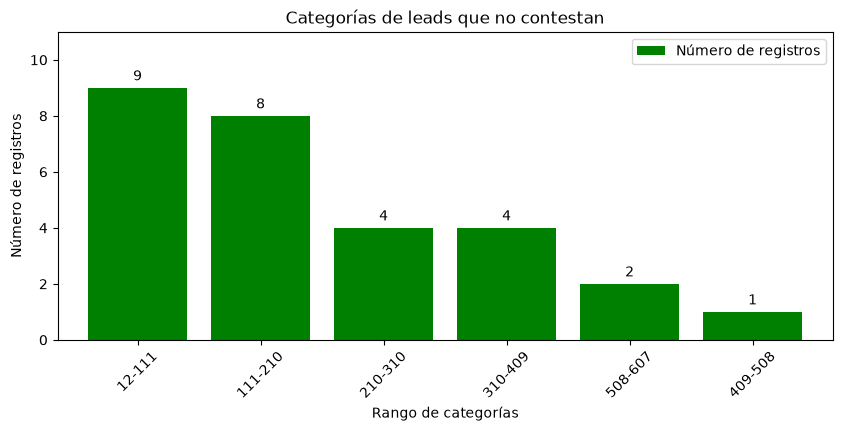

In [41]:
# Gráfica de barras 3: No Contesta

ax = Filtro_NoContesta_index.plot(kind="bar", width=0.8, figsize=(10,4),color="green", rot=45)

ax.bar_label(ax.containers[0], padding=3)

plt.ylim(0, Filtro_NoContesta_index["count"].max() + 2)

plt.title("Categorías de leads que no contestan")
plt.xlabel("Rango de categorías")
plt.ylabel("Número de registros")
plt.legend(["Número de registros"])
plt.show()

In [42]:
# Máximo, mínimo, rango y amplitud de D. Incorrectos

Max_Incorrectos = Leads["D. Incorrectos"].max()
Min_Incorrectos = Leads["D. Incorrectos"].min()
R_Incorrectos = Max_Incorrectos - Min_Incorrectos
i_Incorrectos = R_Incorrectos / numero_intervalos

print("Límites:", [Min_Incorrectos, Max_Incorrectos])
print("Rango:", R_Incorrectos)
print("Amplitud:", i_Incorrectos)

Límites: [np.float64(0.0), np.float64(62.0)]
Rango: 62.0
Amplitud: 10.333333333333334


In [43]:
# Intervalos y categorías

intervalos_Incorrectos = np.linspace(-1, 63, 7)

categorias_Incorrectos = ["-1-10","10-20",
                          "20-31","31-42",
                          "42-52","52-63"]

In [44]:
# Categorizar variable

Leads["Categoria D. Incorrectos"] = pd.cut(x=Leads["D. Incorrectos"], bins=intervalos_Incorrectos,labels=categorias_Incorrectos)

In [45]:
# Tabla, filtro e índice

Tabla_Incorrectos = Leads["Categoria D. Incorrectos"].value_counts().reset_index()
Filtro_Incorrectos = Tabla_Incorrectos[Tabla_Incorrectos["count"] > 0]
Filtro_Incorrectos_index = Filtro_Incorrectos.set_index("Categoria D. Incorrectos")

Filtro_Incorrectos

,Categoria D. Incorrectos,count
0,-1-10,13
1,10-20,6
2,42-52,3
3,20-31,2
4,31-42,2
5,52-63,2


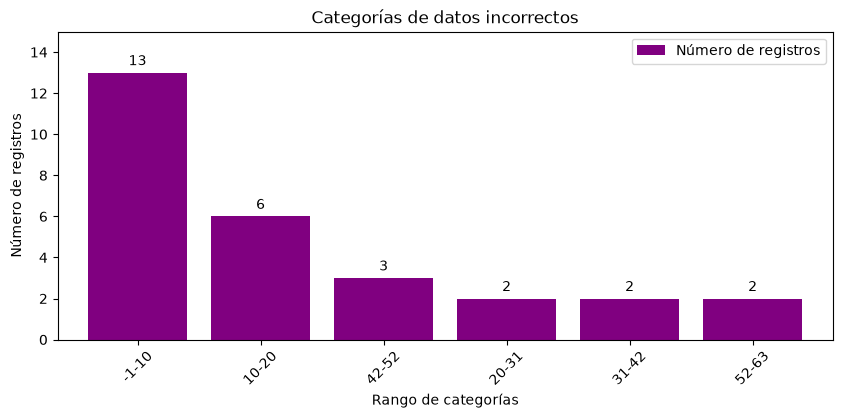

In [46]:
# Gráfica de barras 4: D. Incorrectos

ax = Filtro_Incorrectos_index.plot(kind="bar", width=0.8, figsize=(10,4),color="purple", rot=45)

ax.bar_label(ax.containers[0], padding=3)

plt.ylim(0, Filtro_Incorrectos_index["count"].max() + 2)

plt.title("Categorías de datos incorrectos")
plt.xlabel("Rango de categorías")
plt.ylabel("Número de registros")
plt.legend(["Número de registros"])
plt.show()

In [47]:
# Máximo, mínimo, rango y amplitud de Duplicados

Max_Duplicados = Leads["Duplicados"].max()
Min_Duplicados = Leads["Duplicados"].min()
R_Duplicados = Max_Duplicados - Min_Duplicados
i_Duplicados = R_Duplicados / numero_intervalos

print("Límites:", [Min_Duplicados, Max_Duplicados])
print("Rango:", R_Duplicados)
print("Amplitud:", i_Duplicados)

Límites: [np.float64(0.0), np.float64(136.0)]
Rango: 136.0
Amplitud: 22.666666666666668


In [48]:
# Intervalos y categorías

intervalos_Duplicados = np.linspace(-1, 137, 7)

categorias_Duplicados = ["-1-22","22-45",
                         "45-68","68-91",
                         "91-114","114-137"]

In [49]:
# Categorizar variable

Leads["Categoria Duplicados"] = pd.cut(x=Leads["Duplicados"], bins=intervalos_Duplicados,labels=categorias_Duplicados)

In [50]:
# Tabla, filtro e índice

Tabla_Duplicados = Leads["Categoria Duplicados"].value_counts().reset_index()
Filtro_Duplicados = Tabla_Duplicados[Tabla_Duplicados["count"] > 0]
Filtro_Duplicados_index = Filtro_Duplicados.set_index("Categoria Duplicados")

Filtro_Duplicados

,Categoria Duplicados,count
0,-1-22,13
1,22-45,6
2,45-68,6
3,68-91,1
4,91-114,1
5,114-137,1


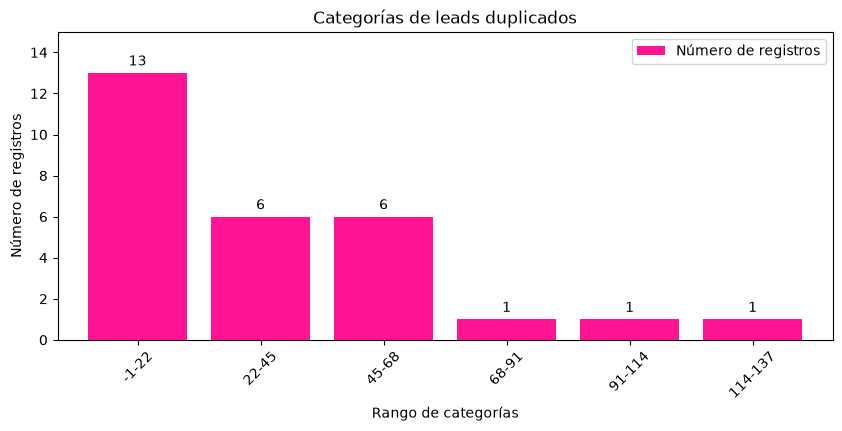

In [51]:
# Gráfica de barras 5: Duplicados

ax = Filtro_Duplicados_index.plot(kind="bar", width=0.8, figsize=(10,4),color="deeppink", rot=45)

ax.bar_label(ax.containers[0], padding=3)

plt.ylim(0, Filtro_Duplicados_index["count"].max() + 2)

plt.title("Categorías de leads duplicados")
plt.xlabel("Rango de categorías")
plt.ylabel("Número de registros")
plt.legend(["Número de registros"])
plt.show()

In [52]:
# Máximo, mínimo, rango y amplitud de Efectivos

Max_Efectivos = Leads["Efectivos"].max()
Min_Efectivos = Leads["Efectivos"].min()
R_Efectivos = Max_Efectivos - Min_Efectivos
i_Efectivos = R_Efectivos / numero_intervalos

print("Límites:", [Min_Efectivos, Max_Efectivos])
print("Rango:", R_Efectivos)
print("Amplitud:", i_Efectivos)

Límites: [np.float64(128.0), np.float64(1040.0)]
Rango: 912.0
Amplitud: 152.0


In [53]:
# Intervalos y categorías

intervalos_Efectivos = np.linspace(127, 1041, 7)

categorias_Efectivos = ["127-279","279-432",
                        "432-584","584-736",
                        "736-889","889-1041"]

In [54]:
# Categorizar variable

Leads["Categoria Efectivos"] = pd.cut(x=Leads["Efectivos"],bins=intervalos_Efectivos,labels=categorias_Efectivos)

In [55]:
# Tabla, filtro e índice

Tabla_Efectivos = Leads["Categoria Efectivos"].value_counts().reset_index()
Filtro_Efectivos = Tabla_Efectivos[Tabla_Efectivos["count"] > 0]
Filtro_Efectivos_index = Filtro_Efectivos.set_index("Categoria Efectivos")

Filtro_Efectivos

,Categoria Efectivos,count
0,584-736,12
1,432-584,5
2,889-1041,4
3,736-889,3
4,127-279,2
5,279-432,2


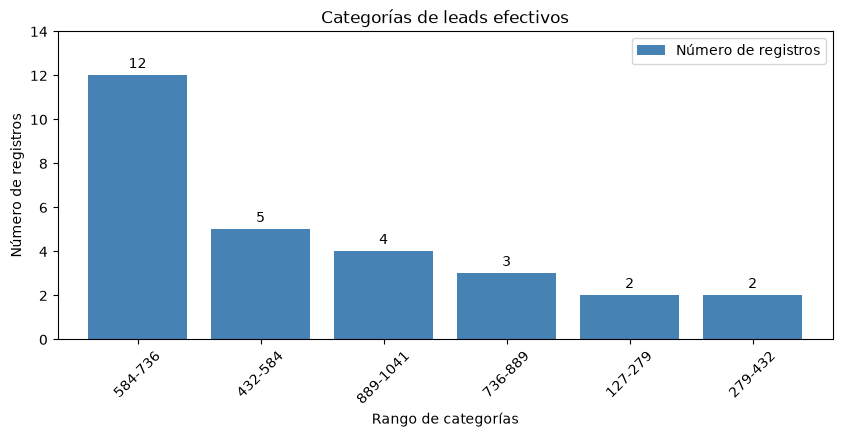

In [56]:
# Gráfica de barras 6: Efectivos

ax = Filtro_Efectivos_index.plot(kind="bar", width=0.8, figsize=(10,4),color="steelblue", rot=45)

ax.bar_label(ax.containers[0], padding=3)

plt.ylim(0, Filtro_Efectivos_index["count"].max() + 2)

plt.title("Categorías de leads efectivos")
plt.xlabel("Rango de categorías")
plt.ylabel("Número de registros")
plt.legend(["Número de registros"])
plt.show()

In [57]:
# Máximo, mínimo, rango y amplitud de Abiertos

Max_Abiertos = Leads["Abiertos"].max()
Min_Abiertos = Leads["Abiertos"].min()
R_Abiertos = Max_Abiertos - Min_Abiertos
i_Abiertos = R_Abiertos / numero_intervalos

print("Límites:", [Min_Abiertos, Max_Abiertos])
print("Rango:", R_Abiertos)
print("Amplitud:", i_Abiertos)

Límites: [np.float64(1.0), np.float64(823.0)]
Rango: 822.0
Amplitud: 137.0


In [58]:
# Intervalos y categorías

intervalos_Abiertos = np.linspace(0, 824, 7)

categorias_Abiertos = ["0-137","137-275",
                       "275-412","412-549",
                       "549-687","687-824"]

In [59]:
# Categorizar variable

Leads["Categoria Abiertos"] = pd.cut(x=Leads["Abiertos"], bins=intervalos_Abiertos,labels=categorias_Abiertos)

In [60]:
# Tabla, filtro e índice

Tabla_Abiertos = Leads["Categoria Abiertos"].value_counts().reset_index()
Filtro_Abiertos = Tabla_Abiertos[Tabla_Abiertos["count"] > 0]
Filtro_Abiertos_index = Filtro_Abiertos.set_index("Categoria Abiertos")

Filtro_Abiertos

,Categoria Abiertos,count
0,0-137,11
1,137-275,5
2,275-412,5
3,412-549,3
4,549-687,2
5,687-824,2


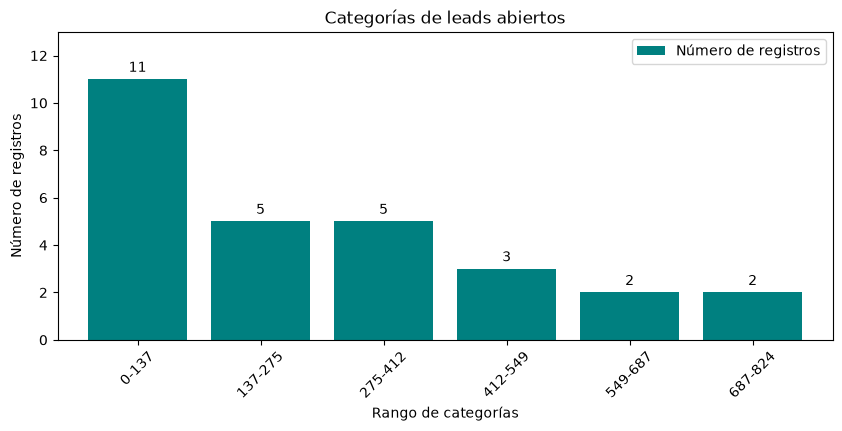

In [61]:
# Gráfica de barras 7: Abiertos

ax = Filtro_Abiertos_index.plot(kind="bar", width=0.8, figsize=(10,4),color="teal", rot=45)

ax.bar_label(ax.containers[0], padding=3)

plt.ylim(0, Filtro_Abiertos_index["count"].max() + 2)

plt.title("Categorías de leads abiertos")
plt.xlabel("Rango de categorías")
plt.ylabel("Número de registros")
plt.legend(["Número de registros"])
plt.show()

In [62]:
# Máximo, mínimo, rango y amplitud de Ventas

Max_Ventas = Leads["Ventas"].max()
Min_Ventas = Leads["Ventas"].min()
R_Ventas = Max_Ventas - Min_Ventas
i_Ventas = R_Ventas / numero_intervalos

print("Límites:", [Min_Ventas, Max_Ventas])
print("Rango:", R_Ventas)
print("Amplitud:", i_Ventas)

Límites: [np.float64(6.0), np.float64(41.0)]
Rango: 35.0
Amplitud: 5.833333333333333


In [63]:
# Intervalos y categorías

intervalos_Ventas = np.linspace(5, 42, 7)

categorias_Ventas = ["5-11","11-17",
                     "17-24","24-30",
                     "30-36","36-42"]

In [64]:
# Categorizar variable

Leads["Categoria Ventas"] = pd.cut(x=Leads["Ventas"],bins=intervalos_Ventas,labels=categorias_Ventas)

In [65]:
# Tabla, filtro e índice

Tabla_Ventas = Leads["Categoria Ventas"].value_counts().reset_index()
Filtro_Ventas = Tabla_Ventas[Tabla_Ventas["count"] > 0]
Filtro_Ventas_index = Filtro_Ventas.set_index("Categoria Ventas")

Filtro_Ventas

,Categoria Ventas,count
0,36-42,8
1,30-36,7
2,11-17,4
3,17-24,4
4,5-11,3
5,24-30,2


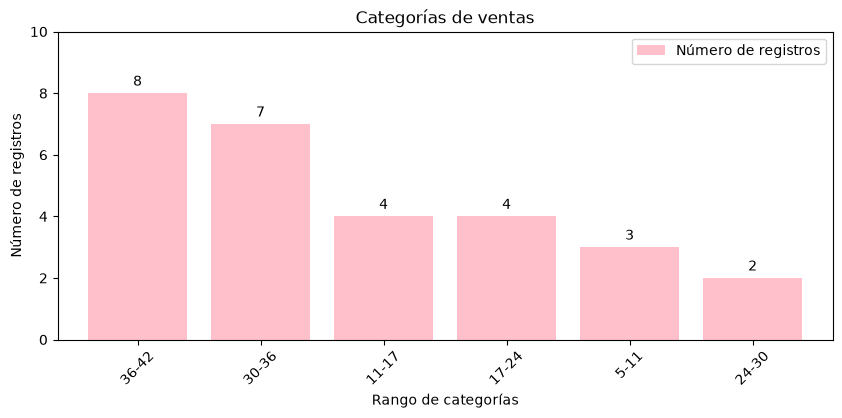

In [66]:
# Gráfica de barras 8: Ventas

ax = Filtro_Ventas_index.plot(kind="bar", width=0.8, figsize=(10,4),color="pink", rot=45)

ax.bar_label(ax.containers[0], padding=3)

plt.ylim(0, Filtro_Ventas_index["count"].max() + 2)

plt.title("Categorías de ventas")
plt.xlabel("Rango de categorías")
plt.ylabel("Número de registros")
plt.legend(["Número de registros"])
plt.show()

In [67]:
# Máximo, mínimo, rango y amplitud de Conversion

Max_Conversion = Leads["Conversion"].max()
Min_Conversion = Leads["Conversion"].min()
R_Conversion = Max_Conversion - Min_Conversion
i_Conversion = R_Conversion / numero_intervalos

print("Límites:", [Min_Conversion, Max_Conversion])
print("Rango:", R_Conversion)
print("Amplitud:", i_Conversion)

Límites: [np.float64(1.0), np.float64(5.9)]
Rango: 4.9
Amplitud: 0.8166666666666668


In [68]:
# Intervalos y categorías

intervalos_Conversion = np.linspace(0.9, 6, 7)

categorias_Conversion = ["0.9%-1.8%","1.8%-2.6%","2.6%-3.5%",
                         "3.5%-4.3%","4.3%-5.2%","5.2%-6.0%"]

In [69]:
# Categorizar variable

Leads["Categoria Conversion"] = pd.cut(x=Leads["Conversion"],bins=intervalos_Conversion,labels=categorias_Conversion)

In [70]:
# Tabla, filtro e índice

Tabla_Conversion = Leads["Categoria Conversion"].value_counts().reset_index()
Filtro_Conversion = Tabla_Conversion[Tabla_Conversion["count"] > 0]
Filtro_Conversion_index = Filtro_Conversion.set_index("Categoria Conversion")

Filtro_Conversion

,Categoria Conversion,count
0,3.5%-4.3%,8
1,5.2%-6.0%,8
2,2.6%-3.5%,7
3,4.3%-5.2%,3
4,0.9%-1.8%,1
5,1.8%-2.6%,1


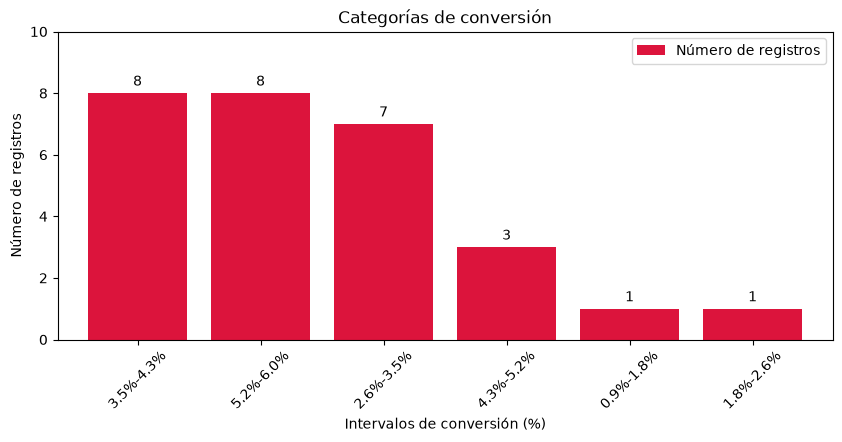

In [71]:
# Gráfica de barras 9: Conversion

ax = Filtro_Conversion_index.plot(kind="bar", width=0.8, figsize=(10,4),color="crimson", rot=45)

ax.bar_label(ax.containers[0], padding=3)

plt.ylim(0, Filtro_Conversion_index["count"].max() + 2)

plt.title("Categorías de conversión")
plt.xlabel("Intervalos de conversión (%)")
plt.ylabel("Número de registros")
plt.legend(["Número de registros"])
plt.show()

In [72]:
# Máximo, mínimo, rango y amplitud de Efectividad de Leads

Max_Efectividad = Leads["Efectividad de Leads"].max()
Min_Efectividad = Leads["Efectividad de Leads"].min()
R_Efectividad = Max_Efectividad - Min_Efectividad
i_Efectividad = R_Efectividad / numero_intervalos

print("Límites:", [Min_Efectividad, Max_Efectividad])
print("Rango:", R_Efectividad)
print("Amplitud:", i_Efectividad)

Límites: [np.float64(39.0), np.float64(83.0)]
Rango: 44.0
Amplitud: 7.333333333333333


In [73]:
# Intervalos y categorías

intervalos_Efectividad = np.linspace(38, 84, 7)

categorias_Efectividad = ["38%-46%","46%-53%","53%-61%",
                          "61%-69%","69%-76%","76%-84%"]

In [74]:
# Categorizar variable

Leads["Categoria Efectividad"] = pd.cut(x=Leads["Efectividad de Leads"], bins=intervalos_Efectividad, labels=categorias_Efectividad)

In [75]:
# Tabla, filtro e índice

Tabla_Efectividad = Leads["Categoria Efectividad"].value_counts().reset_index()
Filtro_Efectividad = Tabla_Efectividad[Tabla_Efectividad["count"] > 0]
Filtro_Efectividad_index = Filtro_Efectividad.set_index("Categoria Efectividad")

Filtro_Efectividad

,Categoria Efectividad,count
0,69%-76%,8
1,46%-53%,5
2,53%-61%,5
3,61%-69%,5
4,38%-46%,3
5,76%-84%,2


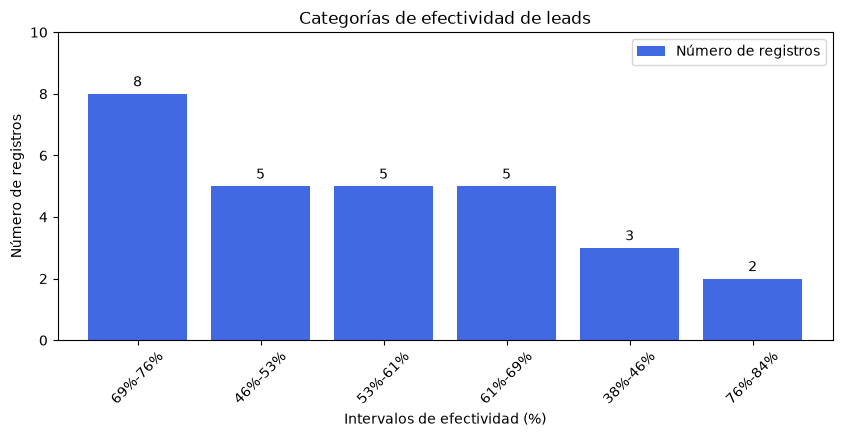

In [76]:
# Gráfica de barras 10: Efectividad de Leads

ax = Filtro_Efectividad_index.plot(kind="bar", width=0.8, figsize=(10,4),color="royalblue", rot=45)

ax.bar_label(ax.containers[0], padding=3)

plt.ylim(0, Filtro_Efectividad_index["count"].max() + 2)

plt.title("Categorías de efectividad de leads")
plt.xlabel("Intervalos de efectividad (%)")
plt.ylabel("Número de registros")
plt.legend(["Número de registros"])
plt.show()